In [1]:
import torch
import torch.nn as nn  #for neural networks
import torch.optim as optim
from torchvision import datasets, transforms,models  #for cvpr models and datasets
from torch.utils.data import DataLoader,Subset,random_split
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
#set seed for reproducibility
#To reproduce same results across runs all the time
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

#Parameters
BATCH_SIZE = 64 
NUM_CLASSES = 10 #for CIFAR 10
NUM_EPOCHS = 20
SUBSET_SIZE = 50000 #CIFAR 10 contains 50000 images, we will use only 2000 for training
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
#Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

])

In [4]:
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset_indices = random.sample(range(len(full_train)), SUBSET_SIZE)
subset_dataset = Subset(full_train, subset_indices)

#split into 90% train and 10% test
train_size = int(0.9 * len(subset_dataset))
test_size = len(subset_dataset) - train_size
train_subset, test_subset = random_split(subset_dataset, [train_size, test_size])
#DataLoader
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

Files already downloaded and verified


In [5]:
def get_vgg16_model(pretrained=True): #false for training from scratch so we will not use imagenet weights
    model = models.vgg16(pretrained=pretrained) #imagenet
    # print(model)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, NUM_CLASSES)
    # print(model)
    for param in model.features.parameters():
        param.requires_grad = False
        
    for param in model.classifier[6].parameters():
        param.requires_grad = True

    return model.to(DEVICE)

In [6]:
def train(model, name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001) #optimizer will only optimize the parameters that require gradients are true

    model.train()
    losses = []
    # 🔹 Early Stopping Parameters
    patience = 5
    best_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False
    print(f"\nTraining model: {name}")
    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / total
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Train Accuracy = {100.*correct/total:.2f}%")
        
        #Early Stopping Logic
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            epochs_no_improve = 0
            #torch.save(model.state_dict(), f'best_model_{name}.pt')  # save best model
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                early_stop = True
                break
    #model.load_state_dict(torch.load(f'best_model_{name}.pt'))
    test_accuracy(model, name)
    return losses

In [7]:
def test_accuracy(model, name):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    print(f"Test Accuracy of {name}: {100. * correct / total:.2f}%")

In [8]:
vgg_pretrained = get_vgg16_model(pretrained=True)
losses_pretrained = train(vgg_pretrained, "VGG16 with Transfer Learning")

/home/rogerthattan/miniconda3/envs/env_gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rogerthattan/miniconda3/envs/env_gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training model: VGG16 with Transfer Learning
Epoch 1: Loss = 0.9669, Train Accuracy = 67.43%
Epoch 2: Loss = 0.7243, Train Accuracy = 76.58%
Epoch 3: Loss = 0.6188, Train Accuracy = 80.07%
Epoch 4: Loss = 0.5509, Train Accuracy = 82.68%
Epoch 5: Loss = 0.4913, Train Accuracy = 84.39%
Epoch 6: Loss = 0.4422, Train Accuracy = 86.17%
Epoch 7: Loss = 0.4074, Train Accuracy = 87.59%
Epoch 8: Loss = 0.3829, Train Accuracy = 88.44%
Epoch 9: Loss = 0.3643, Train Accuracy = 89.26%
Epoch 10: Loss = 0.3373, Train Accuracy = 90.15%
Epoch 11: Loss = 0.3304, Train Accuracy = 90.39%
Epoch 12: Loss = 0.3042, Train Accuracy = 91.32%
Epoch 13: Loss = 0.2874, Train Accuracy = 91.67%
Epoch 14: Loss = 0.2911, Train Accuracy = 91.80%
Epoch 15: Loss = 0.2825, Train Accuracy = 92.17%
Epoch 16: Loss = 0.2639, Train Accuracy = 92.86%
Epoch 17: Loss = 0.2478, Train Accuracy = 93.11%
Epoch 18: Loss = 0.2561, Train Accuracy = 93.21%
Epoch 19: Loss = 0.2310, Train Accuracy = 93.68%
Epoch 20: Loss = 0.2291, Train A

In [9]:
vgg_scratch = get_vgg16_model(pretrained=False)
losses_scratch = train(vgg_scratch, "VGG16 from Scratch")

/home/rogerthattan/miniconda3/envs/env_gpu/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Training model: VGG16 from Scratch
Epoch 1: Loss = 2.0512, Train Accuracy = 21.28%
Epoch 2: Loss = 1.9692, Train Accuracy = 24.23%
Epoch 3: Loss = 1.9438, Train Accuracy = 24.68%
Epoch 4: Loss = 1.9182, Train Accuracy = 25.09%
Epoch 5: Loss = 1.9781, Train Accuracy = 22.90%
Epoch 6: Loss = 1.9928, Train Accuracy = 21.91%
Epoch 7: Loss = 1.9748, Train Accuracy = 22.69%
Epoch 8: Loss = 1.9401, Train Accuracy = 23.86%
Epoch 9: Loss = 1.9499, Train Accuracy = 24.10%
Early stopping triggered at epoch 9.
Test Accuracy of VGG16 from Scratch: 26.26%


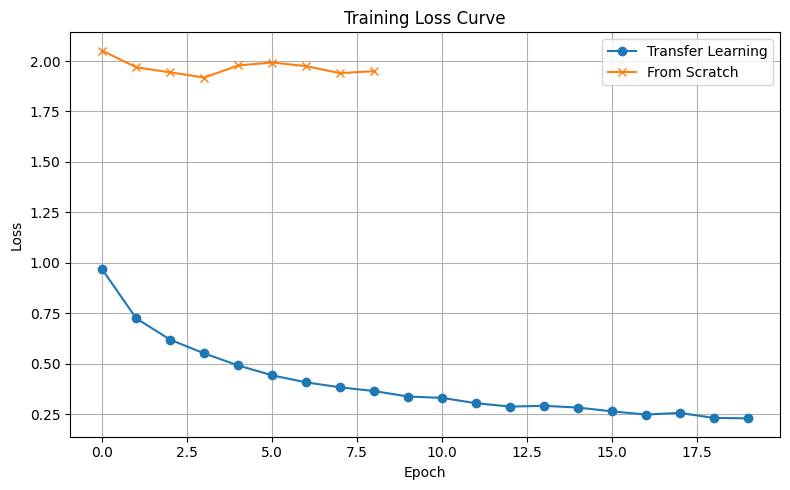

In [10]:
# ========== Plot ==========
plt.figure(figsize=(8, 5))
plt.plot(losses_pretrained, label='Transfer Learning', marker='o')
plt.plot(losses_scratch, label='From Scratch', marker='x')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()